<a href="https://colab.research.google.com/github/sanjogsawant346-ops/CSL701-51_Machine-Learning-Lab/blob/main/Ml_exp_3_cs51_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Experiment Number 3

Name:- Sanjog Sanjiv Sawant

Roll No:- CS51

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# TASK 1: SET UP THE PYTHON ENVIRONMENT

# Import NumPy for numerical and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Display confirmation
print("Python environment set up successfully!")
print("NumPy version:", np.__version__)

Python environment set up successfully!
NumPy version: 2.1.3


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# TASK 2: LOAD AND INSPECT THE DATASET

import pandas as pd
from google.colab import files

# Upload CSV file manually
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Display the first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Identify numerical attributes
numerical_attributes = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nNumerical attributes:")
print(numerical_attributes)

# Identify categorical attributes
categorical_attributes = df.select_dtypes(include=['object']).columns.tolist()

print("\nCategorical attributes:")
print(categorical_attributes)

# Separate selling_price as target variable
y = df['selling_price']

print("\nTarget variable: selling_price")
display(y.head())

Saving archive.zip to archive.zip
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# TASK 3: CHECK AND HANDLE MISSING DATA

# Check missing values in each column
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Display total number of missing values
total_missing = df.isnull().sum().sum()
print("\nTotal missing values:", total_missing)

# Handle missing values
# Numerical columns -> replace missing values with median
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Categorical columns -> replace missing values with mode
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values after preprocessing
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Verify that the dataset contains no missing values
if df.isnull().sum().sum() == 0:
    print("\nNo missing values found. Dataset is ready for further processing.")
else:
    print("\nMissing values are still present.")

# Record preprocessing method
print("\nPreprocessing method used:")
print("Numerical attributes: Missing values replaced with median.")
print("Categorical attributes: Missing values replaced with mode.")

Missing values before preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

No missing values found. Dataset is ready for further processing.

Preprocessing method used:
Numerical attributes: Missing values replaced with median.
Categorical attributes: Missing values replaced with mode.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# TASK 4: SELECT AND PREPARE FEATURES

# Display all available attributes
print("Available attributes:")
print(df.columns.tolist())

# Display data types
print("\nData types of attributes:")
print(df.dtypes)

# Handle Car_Name
# Car_Name is a text/categorical attribute, so it is not used directly
print("\nCar_Name is excluded because it is a categorical/text attribute.")

# Select meaningful numerical predictor variables
features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Create predictor matrix X
X = df[features].copy()

# Create target vector y
y = df['selling_price'].copy()

# Convert X and y to NumPy arrays for matrix operations
X = X.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)

# Display the predictor matrix
print("\nPredictor matrix X:")
print(X[:5])

# Display target vector
print("\nTarget vector y:")
print(y[:5])

# Display dimensions
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display final selected features
print("\nFinal features selected for the model:")
for feature in features:
    print("-", feature)


Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Data types of attributes:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Car_Name is excluded because it is a categorical/text attribute.

Predictor matrix X:
[[9.000e+00 1.200e+05 1.970e+01 7.960e+02 4.630e+01 5.000e+00]
 [5.000e+00 2.000e+04 1.890e+01 1.197e+03 8.200e+01 5.000e+00]
 [1.100e+01 6.000e+04 1.700e+01 1.197e+03 8.000e+01 5.000e+00]
 [9.000e+00 3.700e+04 2.092e+01 9.980e+02 6.710e+01 5.000e+00]
 [6.000e+0

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# TASK 5: ENCODE CATEGORICAL VARIABLES

# Display the categorical variables
categorical_features = [
    'fuel_type',
    'seller_type',
    'transmission_type'
]

print("Categorical variables:")
print(categorical_features)

# Display categorical data before encoding
print("\nCategorical data before encoding:")
display(df[categorical_features].head())

# Perform one-hot encoding
# drop_first=True avoids unnecessary duplicate information
encoded_data = pd.get_dummies(
    df[categorical_features],
    drop_first=True,
    dtype=int
)

# Display the encoded variables
print("\nEncoded categorical variables:")
display(encoded_data.head())

# Select numerical predictor variables
numerical_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Create the complete predictor dataset
X_df = pd.concat(
    [df[numerical_features], encoded_data],
    axis=1
)

# Create target variable
y = df['selling_price']

# Verify that all predictors are numerical
print("\nData types after encoding:")
print(X_df.dtypes)

# Check whether any non-numerical columns remain
non_numeric = X_df.select_dtypes(exclude=['number']).columns

print("\nNon-numerical predictor columns:")
print(list(non_numeric))

if len(non_numeric) == 0:
    print("All predictor variables are numerical.")

# Display the transformed dataset
print("\nTransformed dataset:")
display(X_df.head())

# Display dimensions
print("\nShape of transformed predictor matrix X:", X_df.shape)

Categorical variables:
['fuel_type', 'seller_type', 'transmission_type']

Categorical data before encoding:


,fuel_type,seller_type,transmission_type
0,Petrol,Individual,Manual
1,Petrol,Individual,Manual
2,Petrol,Individual,Manual
3,Petrol,Individual,Manual
4,Diesel,Dealer,Manual



Encoded categorical variables:


,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,0,0,0,1,1,0,1
1,0,0,0,1,1,0,1
2,0,0,0,1,1,0,1
3,0,0,0,1,1,0,1
4,1,0,0,0,0,0,1



Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object

Non-numerical predictor columns:
[]
All predictor variables are numerical.

Transformed dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0,0,0,1,1,0,1
1,5,20000,18.90,1197,82.00,5,0,0,0,1,1,0,1
2,11,60000,17.00,1197,80.00,5,0,0,0,1,1,0,1
3,9,37000,20.92,998,67.10,5,0,0,0,1,1,0,1
4,6,30000,22.77,1498,98.59,5,1,0,0,0,0,0,1



Shape of transformed predictor matrix X: (15411, 13)


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Perform Feature Engineering
# ============================================================
# TASK 6: PERFORM FEATURE ENGINEERING
# ============================================================

# Check whether Year exists
if 'Year' in df.columns:

    # Get current year
    current_year = pd.Timestamp.now().year

    # Create Car_Age
    df['Car_Age'] = current_year - df['Year']

    # Display values
    print("Year and Car_Age:")
    display(df[['Year', 'Car_Age']].head(10))

    # Check age range
    print("\nMinimum Car Age:", df['Car_Age'].min())
    print("Maximum Car Age:", df['Car_Age'].max())

else:

    print("The dataset does not contain a 'Year' column.")
    print("The dataset already contains 'vehicle_age'.")

    # Use existing vehicle_age as Car_Age
    df['Car_Age'] = df['vehicle_age']

    print("\nCreated Car_Age using the existing vehicle_age feature.")

    # Display values
    print("\nVehicle Age and Car_Age:")
    display(df[['vehicle_age', 'Car_Age']].head(10))

    # Check age range
    print("\nMinimum Car Age:", df['Car_Age'].min())
    print("Maximum Car Age:", df['Car_Age'].max())

# ------------------------------------------------------------
# Verify ages are reasonable
# ------------------------------------------------------------

if df['Car_Age'].min() >= 0 and df['Car_Age'].max() <= 100:
    print("\nSUCCESS: Car ages are within a reasonable range.")
else:
    print("\nWarning: Check the calculated car ages.")

# ------------------------------------------------------------
# Decision about original feature
# ------------------------------------------------------------

print("\nDecision:")
print("The original 'vehicle_age' feature can be removed after")
print("creating Car_Age because both represent the same information.")



The dataset does not contain a 'Year' column.
The dataset already contains 'vehicle_age'.

Created Car_Age using the existing vehicle_age feature.

Vehicle Age and Car_Age:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum Car Age: 0
Maximum Car Age: 29

SUCCESS: Car ages are within a reasonable range.

Decision:
The original 'vehicle_age' feature can be removed after
creating Car_Age because both represent the same information.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

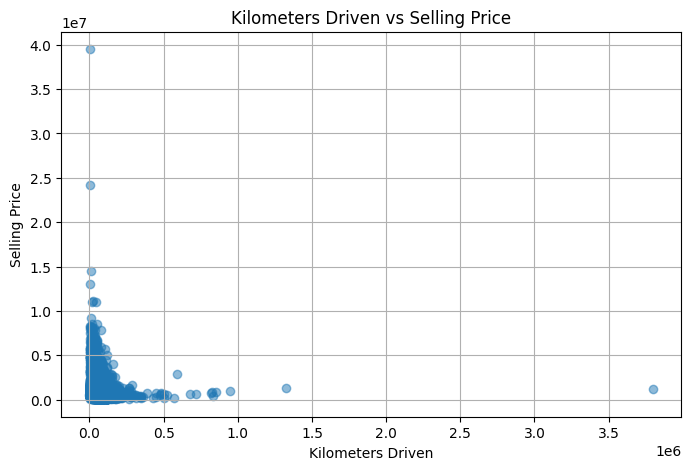

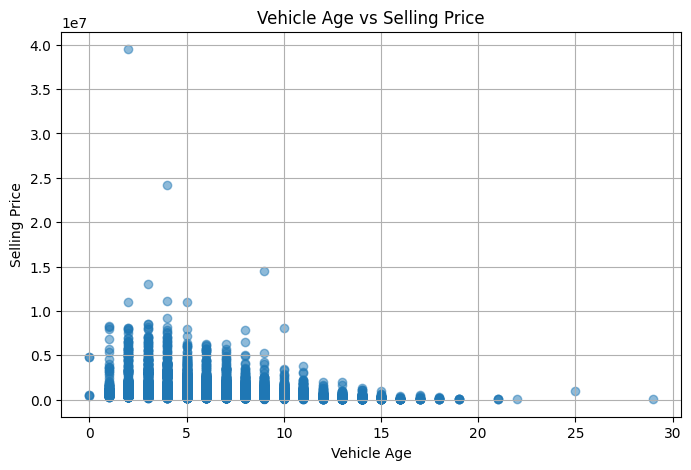

In [ ]:
# ============================================================
# TASK 7: EXPLORATORY DATA ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Scatter Plot: km_driven vs selling_price
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(df['km_driven'], df['selling_price'], alpha=0.5)

plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.title('Kilometers Driven vs Selling Price')

plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 2. Scatter Plot: vehicle_age vs selling_price
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(df['vehicle_age'], df['selling_price'], alpha=0.5)

plt.xlabel('Vehicle Age')
plt.ylabel('Selling Price')
plt.title('Vehicle Age vs Selling Price')

plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# ============================================================
# TASK 8: STANDARDIZE NUMERICAL FEATURES
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Define numerical predictor variables
# ------------------------------------------------------------

numerical_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Target variable
target = 'selling_price'

# ------------------------------------------------------------
# 2. Create X and y
# ------------------------------------------------------------

X = df[numerical_features].copy()
y = df[target].copy()

print("Numerical Predictors:")
print(numerical_features)

print("\nTarget Variable:")
print(target)

# ------------------------------------------------------------
# 3. Split data into training and testing sets
# ------------------------------------------------------------

# 80% Training and 20% Testing
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ------------------------------------------------------------
# 4. Calculate mean and standard deviation using TRAINING data
# ------------------------------------------------------------

train_mean = X_train.mean()
train_std = X_train.std()

print("\nTraining Mean:")
print(train_mean)

print("\nTraining Standard Deviation:")
print(train_std)

# ------------------------------------------------------------
# 5. Standardization formula
# ------------------------------------------------------------
# z = (x - mean) / standard deviation

X_train_standardized = (X_train - train_mean) / train_std

# ------------------------------------------------------------
# 6. Use SAME training mean and std for test data
# ------------------------------------------------------------

X_test_standardized = (X_test - train_mean) / train_std

# ------------------------------------------------------------
# 7. Display standardized training data
# ------------------------------------------------------------

print("\nStandardized Training Features:")
display(X_train_standardized.head())

# ------------------------------------------------------------
# 8. Display standardized test data
# ------------------------------------------------------------

print("\nStandardized Test Features:")
display(X_test_standardized.head())

# ------------------------------------------------------------
# 9. Verify training means are approximately 0
# ------------------------------------------------------------

print("\nMean of Standardized Training Features:")
print(X_train_standardized.mean())

# ------------------------------------------------------------
# 10. Verify training standard deviations are approximately 1
# ------------------------------------------------------------

print("\nStandard Deviation of Standardized Training Features:")
print(X_train_standardized.std())

# ------------------------------------------------------------
# 11. Verify target variable was NOT standardized
# ------------------------------------------------------------

print("\nTarget Variable:")
print("selling_price was NOT standardized.")

print("\nOriginal Training Target Values:")
print(y_train.head())


Numerical Predictors:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Target Variable:
selling_price

Training Data Shape: (12328, 6)
Testing Data Shape: (3083, 6)

Training Mean:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training Standard Deviation:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized Training Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974



Standardized Test Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
15384,-1.004497,-0.563448,-2.322552,1.279117,1.625503,-0.402974
147,0.651752,0.409508,-0.752864,0.931826,1.099368,-0.402974
1668,0.320502,0.124964,1.320084,-0.457339,-0.620337,-0.402974
11280,-0.341998,-0.563448,1.348841,-0.553809,-0.550155,0.832199
13650,-1.004497,-0.618521,-0.357446,-0.551879,-0.276443,-0.402974



Mean of Standardized Training Features:
vehicle_age   -1.786731e-17
km_driven      3.342917e-17
mileage       -1.809786e-16
engine         2.132550e-17
max_power      7.665654e-17
seats         -1.083566e-16
dtype: float64

Standard Deviation of Standardized Training Features:
vehicle_age    1.0
km_driven      1.0
mileage        1.0
engine         1.0
max_power      1.0
seats          1.0
dtype: float64

Target Variable:
selling_price was NOT standardized.

Original Training Target Values:
3334      190000
10928     600000
2518      665000
11322    1570000
9394      160000
Name: selling_price, dtype: int64


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# ============================================================
# TASK 9: SPLIT THE DATASET
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Set random seed for reproducibility
# ------------------------------------------------------------

np.random.seed(42)

# ------------------------------------------------------------
# 2. Get total number of observations
# ------------------------------------------------------------

n = len(X)

# ------------------------------------------------------------
# 3. Randomly shuffle the observation indices
# ------------------------------------------------------------

indices = np.random.permutation(n)

# ------------------------------------------------------------
# 4. Calculate 80% training size
# ------------------------------------------------------------

train_size = int(0.80 * n)

# ------------------------------------------------------------
# 5. Create training and testing indices
# ------------------------------------------------------------

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# ------------------------------------------------------------
# 6. Create training and testing datasets
# ------------------------------------------------------------

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# ------------------------------------------------------------
# 7. Display number of observations
# ------------------------------------------------------------

print("Total Observations:", n)

print("\nTraining Set:")
print("Number of Observations:", len(X_train))

print("\nTesting Set:")
print("Number of Observations:", len(X_test))

# ------------------------------------------------------------
# 8. Display shapes
# ------------------------------------------------------------

print("\nTraining Feature Shape:", X_train.shape)
print("Training Target Shape:", y_train.shape)

print("\nTesting Feature Shape:", X_test.shape)
print("Testing Target Shape:", y_test.shape)

# ------------------------------------------------------------
# 9. Verify total observations
# ------------------------------------------------------------

print("\nVerification:")
print("Training + Testing =", len(X_train) + len(X_test))
print("Total Dataset      =", n)

if len(X_train) + len(X_test) == n:
    print("SUCCESS: All observations are accounted for.")

Total Observations: 15411

Training Set:
Number of Observations: 12328

Testing Set:
Number of Observations: 3083

Training Feature Shape: (12328, 6)
Training Target Shape: (12328,)

Testing Feature Shape: (3083, 6)
Testing Target Shape: (3083,)

Verification:
Training + Testing = 15411
Total Dataset      = 15411
SUCCESS: All observations are accounted for.


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# ============================================================
# TASK 10: CONSTRUCT THE FEATURE MATRIX
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Create training feature matrix Xtrain
# ------------------------------------------------------------

Xtrain = X_train.to_numpy()

# ------------------------------------------------------------
# 2. Create training target vector ytrain
# ------------------------------------------------------------

ytrain = y_train.to_numpy()

# ------------------------------------------------------------
# 3. Create testing feature matrix Xtest
# ------------------------------------------------------------

Xtest = X_test.to_numpy()

# ------------------------------------------------------------
# 4. Create testing target vector ytest
# ------------------------------------------------------------

ytest = y_test.to_numpy()

# ------------------------------------------------------------
# 5. Display the matrices/vectors
# ------------------------------------------------------------

print("Xtrain - Training Feature Matrix")
print(Xtrain[:5])

print("\nytrain - Training Target Vector")
print(ytrain[:5])

print("\nXtest - Testing Feature Matrix")
print(Xtest[:5])

print("\nytest - Testing Target Vector")
print(ytest[:5])

# ------------------------------------------------------------
# 6. Display shapes
# ------------------------------------------------------------

print("\n================ MATRIX SHAPES ================")

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

# ------------------------------------------------------------
# 7. Verify number of rows and predictor columns
# ------------------------------------------------------------

print("\n================ VERIFICATION ================")

print("Training rows:", Xtrain.shape[0])
print("Training predictor columns:", Xtrain.shape[1])

print("Testing rows:", Xtest.shape[0])
print("Testing predictor columns:", Xtest.shape[1])

# ------------------------------------------------------------
# 8. Verify X and y have matching number of observations
# ------------------------------------------------------------

if Xtrain.shape[0] == ytrain.shape[0]:
    print("\nSUCCESS: Xtrain and ytrain have matching rows.")
else:
    print("\nERROR: Xtrain and ytrain row counts do not match.")

if Xtest.shape[0] == ytest.shape[0]:
    print("SUCCESS: Xtest and ytest have matching rows.")
else:
    print("ERROR: Xtest and ytest row counts do not match.")


Xtrain - Training Feature Matrix
[[1.2000e+01 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00]
 [4.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01 5.0000e+00]
 [7.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01 7.0000e+00]
 [1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02 5.0000e+00]
 [1.1000e+01 6.2000e+04 1.9700e+01 7.9600e+02 4.6300e+01 5.0000e+00]]

ytrain - Training Target Vector
[ 190000  600000  665000 1570000  160000]

Xtest - Testing Feature Matrix
[[3.0000e+00 2.5000e+04 1.0000e+01 2.1480e+03 1.7000e+02 5.0000e+00]
 [8.0000e+00 7.8000e+04 1.6550e+01 1.9680e+03 1.4751e+02 5.0000e+00]
 [7.0000e+00 6.2500e+04 2.5200e+01 1.2480e+03 7.4000e+01 5.0000e+00]
 [5.0000e+00 2.5000e+04 2.5320e+01 1.1980e+03 7.7000e+01 6.0000e+00]
 [3.0000e+00 2.2000e+04 1.8200e+01 1.1990e+03 8.8700e+01 5.0000e+00]]

ytest - Testing Target Vector
[4450000 1290000  485000  400000  800000]

================ MATRIX SHAPES ================
Xtrain shape: (12328, 6)
ytrain shape: (12328,

## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# ============================================================
# TASK 11: ADD THE BIAS / INTERCEPT TERM
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Create a column of 1s for the intercept
# ------------------------------------------------------------

bias_train = np.ones((Xtrain.shape[0], 1))
bias_test = np.ones((Xtest.shape[0], 1))

# ------------------------------------------------------------
# 2. Add the bias column to the beginning of Xtrain
# ------------------------------------------------------------

Xtrain_bias = np.hstack((bias_train, Xtrain))

# ------------------------------------------------------------
# 3. Add the bias column to the beginning of Xtest
# ------------------------------------------------------------

Xtest_bias = np.hstack((bias_test, Xtest))

# ------------------------------------------------------------
# 4. Display the first few rows
# ------------------------------------------------------------

print("Xtrain with Bias Column:")
print(Xtrain_bias[:5])

print("\nXtest with Bias Column:")
print(Xtest_bias[:5])

# ------------------------------------------------------------
# 5. Display the new dimensions
# ------------------------------------------------------------

print("\n================ MATRIX SHAPES ================")

print("Original Xtrain shape:", Xtrain.shape)
print("New Xtrain shape:", Xtrain_bias.shape)

print("\nOriginal Xtest shape:", Xtest.shape)
print("New Xtest shape:", Xtest_bias.shape)

# ------------------------------------------------------------
# 6. Verify the first column contains only 1s
# ------------------------------------------------------------

print("\nFirst 5 values of Xtrain bias column:")
print(Xtrain_bias[:5, 0])

print("\nFirst 5 values of Xtest bias column:")
print(Xtest_bias[:5, 0])

# ------------------------------------------------------------
# 7. Verify bias column
# ------------------------------------------------------------

if np.all(Xtrain_bias[:, 0] == 1):
    print("\nSUCCESS: Training bias column contains only 1.0.")

if np.all(Xtest_bias[:, 0] == 1):
    print("SUCCESS: Testing bias column contains only 1.0.")

Xtrain with Bias Column:
[[1.0000e+00 1.2000e+01 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01
  5.0000e+00]
 [1.0000e+00 4.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 7.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01
  7.0000e+00]
 [1.0000e+00 1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02
  5.0000e+00]
 [1.0000e+00 1.1000e+01 6.2000e+04 1.9700e+01 7.9600e+02 4.6300e+01
  5.0000e+00]]

Xtest with Bias Column:
[[1.0000e+00 3.0000e+00 2.5000e+04 1.0000e+01 2.1480e+03 1.7000e+02
  5.0000e+00]
 [1.0000e+00 8.0000e+00 7.8000e+04 1.6550e+01 1.9680e+03 1.4751e+02
  5.0000e+00]
 [1.0000e+00 7.0000e+00 6.2500e+04 2.5200e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 5.0000e+00 2.5000e+04 2.5320e+01 1.1980e+03 7.7000e+01
  6.0000e+00]
 [1.0000e+00 3.0000e+00 2.2000e+04 1.8200e+01 1.1990e+03 8.8700e+01
  5.0000e+00]]

================ MATRIX SHAPES ================
Original Xtrain shape: (12328, 6)
New Xtrain shape: (12328, 7)

Original Xtest 

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# ============================================================
# TASK 12: IMPLEMENT THE OLS FUNCTION
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Define the OLS function
# ------------------------------------------------------------

def ols(X, y):

    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate inverse of X^T X
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate beta using the normal equation
    beta = XTX_inverse @ XTy

    # Return coefficient vector
    return beta


# ------------------------------------------------------------
# 2. Calculate regression coefficients
# ------------------------------------------------------------

beta = ols(Xtrain_bias, ytrain)


# ------------------------------------------------------------
# 3. Display X^T X
# ------------------------------------------------------------

XTX = Xtrain_bias.T @ Xtrain_bias

print("Matrix X^T X:")
print(XTX)


# ------------------------------------------------------------
# 4. Display X^T y
# ------------------------------------------------------------

XTy = Xtrain_bias.T @ ytrain

print("\nMatrix X^T y:")
print(XTy)


# ------------------------------------------------------------
# 5. Display coefficient vector
# ------------------------------------------------------------

print("\nRegression Coefficient Vector (Beta):")
print(beta)


# ------------------------------------------------------------
# 6. Display coefficient names
# ------------------------------------------------------------

feature_names = [
    'Intercept',
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

print("\nRegression Coefficients:")
for name, coefficient in zip(feature_names, beta):
    print(f"{name}: {coefficient:.6f}")


# ------------------------------------------------------------
# 7. Verify dimensions
# ------------------------------------------------------------

print("\n================ DIMENSION VERIFICATION ================")

print("Xtrain_bias shape:", Xtrain_bias.shape)
print("X^T X shape:", XTX.shape)
print("X^T y shape:", XTy.shape)
print("Beta shape:", beta.shape)

Matrix X^T X:
[[1.23280000e+04 7.43680000e+04 6.86581080e+08 2.42757450e+05
  1.83075410e+07 1.23917046e+06 6.56620000e+04]
 [7.43680000e+04 5.60964000e+05 4.77914330e+09 1.42440640e+06
  1.12304551e+08 7.47466506e+06 3.97047000e+05]
 [6.86581080e+08 4.77914330e+09 7.48158585e+13 1.32306421e+10
  1.08544250e+12 7.02574380e+10 3.75928776e+09]
 [2.42757450e+05 1.42440640e+06 1.32306421e+10 4.99491204e+06
  3.43664005e+08 2.32305586e+07 1.27476741e+06]
 [1.83075410e+07 1.12304551e+08 1.08544250e+12 3.43664005e+08
  3.04988067e+10 2.05969110e+09 1.00365680e+08]
 [1.23917046e+06 7.47466506e+06 7.02574380e+10 2.32305586e+07
  2.05969110e+09 1.47081203e+08 6.67368955e+06]
 [6.56620000e+04 3.97047000e+05 3.75928776e+09 1.27476741e+06
  1.00365680e+08 6.67368955e+06 3.57812000e+05]]

Matrix X^T y:
[9.56343088e+09 4.95380801e+10 4.87101037e+14 1.74333375e+11
 1.75157919e+13 1.31593027e+12 5.19381334e+10]

Regression Coefficient Vector (Beta):
[-7.65870856e+05 -6.50147792e+04 -6.77550257e-01  1.3

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# ============================================================
# TASK 13: CHECK MATRIX SINGULARITY
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Calculate X^T X
# ------------------------------------------------------------

XTX = Xtrain_bias.T @ Xtrain_bias

print("Matrix X^T X:")
print(XTX)

# ------------------------------------------------------------
# 2. Calculate determinant of X^T X
# ------------------------------------------------------------

det_XTX = np.linalg.det(XTX)

print("\nDeterminant of X^T X:")
print(det_XTX)

# ------------------------------------------------------------
# 3. Check whether the matrix is singular
# ------------------------------------------------------------

tolerance = 1e-10

if np.isclose(det_XTX, 0, atol=tolerance):
    print("\nRESULT: X^T X is singular or nearly singular.")
    print("Feature redundancy or multicollinearity should be investigated.")
else:
    print("\nRESULT: X^T X is not singular.")
    print("The matrix can be used for the OLS calculation.")

# ------------------------------------------------------------
# 4. Calculate the condition number
# ------------------------------------------------------------

condition_number = np.linalg.cond(XTX)

print("\nCondition Number of X^T X:")
print(condition_number)

# ------------------------------------------------------------
# 5. Interpret the condition number
# ------------------------------------------------------------

if condition_number < 100:
    print("\nInterpretation: Low multicollinearity.")
elif condition_number < 1000:
    print("\nInterpretation: Moderate multicollinearity.")
else:
    print("\nInterpretation: High multicollinearity may be present.")

# ------------------------------------------------------------
# 6. Display matrix dimensions
# ------------------------------------------------------------

print("\nShape of X^T X:", XTX.shape)


Matrix X^T X:
[[1.23280000e+04 7.43680000e+04 6.86581080e+08 2.42757450e+05
  1.83075410e+07 1.23917046e+06 6.56620000e+04]
 [7.43680000e+04 5.60964000e+05 4.77914330e+09 1.42440640e+06
  1.12304551e+08 7.47466506e+06 3.97047000e+05]
 [6.86581080e+08 4.77914330e+09 7.48158585e+13 1.32306421e+10
  1.08544250e+12 7.02574380e+10 3.75928776e+09]
 [2.42757450e+05 1.42440640e+06 1.32306421e+10 4.99491204e+06
  3.43664005e+08 2.32305586e+07 1.27476741e+06]
 [1.83075410e+07 1.12304551e+08 1.08544250e+12 3.43664005e+08
  3.04988067e+10 2.05969110e+09 1.00365680e+08]
 [1.23917046e+06 7.47466506e+06 7.02574380e+10 2.32305586e+07
  2.05969110e+09 1.47081203e+08 6.67368955e+06]
 [6.56620000e+04 3.97047000e+05 3.75928776e+09 1.27476741e+06
  1.00365680e+08 6.67368955e+06 3.57812000e+05]]

Determinant of X^T X:
4.812491773078243e+47

RESULT: X^T X is not singular.
The matrix can be used for the OLS calculation.

Condition Number of X^T X:
1222348027225.2598

Interpretation: High multicollinearity may

## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# ============================================================
# TASK 14: TRAIN THE REGRESSION MODEL
# ============================================================

# ------------------------------------------------------------
# 1. Apply OLS to the training dataset
# ------------------------------------------------------------

beta = ols(Xtrain_bias, ytrain)

# ------------------------------------------------------------
# 2. Display the complete regression coefficient vector
# ------------------------------------------------------------

print("Regression Coefficient Vector (Beta):")
print(beta)

# ------------------------------------------------------------
# 3. Define feature names
# ------------------------------------------------------------

feature_names = [
    'Intercept',
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# ------------------------------------------------------------
# 4. Display intercept coefficient
# ------------------------------------------------------------

beta_0 = beta[0]

print("\nIntercept Coefficient (β0):")
print(beta_0)

# ------------------------------------------------------------
# 5. Display each feature coefficient
# ------------------------------------------------------------

print("\nRegression Coefficients:")
print("----------------------------------------")

for feature, coefficient in zip(feature_names, beta):
    print(f"{feature:15s} : {coefficient:.6f}")

# ------------------------------------------------------------
# 6. Create a coefficient table
# ------------------------------------------------------------

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': beta
})

print("\nCoefficient Table:")
display(coefficient_table)

Regression Coefficient Vector (Beta):
[-7.65870856e+05 -6.50147792e+04 -6.77550257e-01  1.37530571e+04
  7.58158512e+01  1.57543776e+04  8.57129320e+02]

Intercept Coefficient (β0):
-765870.855685398

Regression Coefficients:
----------------------------------------
Intercept       : -765870.855685
vehicle_age     : -65014.779175
km_driven       : -0.677550
mileage         : 13753.057078
engine          : 75.815851
max_power       : 15754.377629
seats           : 857.129320

Coefficient Table:


,Feature,Coefficient
0,Intercept,-765870.855685
1,vehicle_age,-65014.779175
2,km_driven,-0.677550
3,mileage,13753.057078
4,engine,75.815851
5,max_power,15754.377629
6,seats,857.129320


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# ============================================================
# TASK 15: INTERPRET THE REGRESSION COEFFICIENTS
# ============================================================

# Feature names corresponding to beta coefficients
feature_names = [
    'Intercept',
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# ------------------------------------------------------------
# 1. Create coefficient table
# ------------------------------------------------------------

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': beta
})

# Add sign
coefficient_table['Sign'] = coefficient_table['Coefficient'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative'
)

# Absolute coefficient for comparing influence
coefficient_table['Absolute_Value'] = coefficient_table['Coefficient'].abs()

print("Regression Coefficient Interpretation:")
display(coefficient_table)

# ------------------------------------------------------------
# 2. Display positive and negative coefficients
# ------------------------------------------------------------

print("\nPositive Coefficients:")

for feature, coefficient in zip(feature_names[1:], beta[1:]):
    if coefficient > 0:
        print(f"{feature}: {coefficient:.6f}")

print("\nNegative Coefficients:")

for feature, coefficient in zip(feature_names[1:], beta[1:]):
    if coefficient < 0:
        print(f"{feature}: {coefficient:.6f}")

# ------------------------------------------------------------
# 3. Rank features by absolute coefficient
# ------------------------------------------------------------

importance = coefficient_table.iloc[1:].sort_values(
    by='Absolute_Value',
    ascending=False
)

print("\nFeatures Ranked by Relative Influence:")
display(importance[['Feature', 'Coefficient', 'Absolute_Value']])

Regression Coefficient Interpretation:


,Feature,Coefficient,Sign,Absolute_Value
0,Intercept,-765870.855685,Negative,765870.855685
1,vehicle_age,-65014.779175,Negative,65014.779175
2,km_driven,-0.677550,Negative,0.677550
3,mileage,13753.057078,Positive,13753.057078
4,engine,75.815851,Positive,75.815851
5,max_power,15754.377629,Positive,15754.377629
6,seats,857.129320,Positive,857.129320



Positive Coefficients:
mileage: 13753.057078
engine: 75.815851
max_power: 15754.377629
seats: 857.129320

Negative Coefficients:
vehicle_age: -65014.779175
km_driven: -0.677550

Features Ranked by Relative Influence:


,Feature,Coefficient,Absolute_Value
1,vehicle_age,-65014.779175,65014.779175
5,max_power,15754.377629,15754.377629
3,mileage,13753.057078,13753.057078
6,seats,857.129320,857.129320
4,engine,75.815851,75.815851
2,km_driven,-0.677550,0.677550


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# ============================================================
# TASK 16: PREDICT SELLING PRICES
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Predict selling prices for the test dataset
# ------------------------------------------------------------

y_pred = Xtest_bias @ beta

# ------------------------------------------------------------
# 2. Display first 10 predicted values
# ------------------------------------------------------------

print("First 10 Predicted Selling Prices:")
print(y_pred[:10])

# ------------------------------------------------------------
# 3. Compare actual and predicted selling prices
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Actual Selling Price': ytest,
    'Predicted Selling Price': y_pred
})

print("\nActual vs Predicted Selling Prices:")
display(comparison.head(10))

# ------------------------------------------------------------
# 4. Calculate prediction error
# ------------------------------------------------------------

comparison['Error'] = (
    comparison['Actual Selling Price']
    - comparison['Predicted Selling Price']
)

print("\nActual vs Predicted with Error:")
display(comparison.head(10))

# ------------------------------------------------------------
# 5. Display dimensions
# ------------------------------------------------------------

print("\nNumber of Test Observations:", len(ytest))
print("Number of Predictions:", len(y_pred))

# ------------------------------------------------------------
# 6. Verify that prediction count matches test data
# ------------------------------------------------------------

if len(y_pred) == len(ytest):
    print("\nSUCCESS: Number of predictions matches test observations.")
else:
    print("\nERROR: Prediction count does not match test observations.")

First 10 Predicted Selling Prices:
[2005058.91302346 1366194.57127365  347983.61080247  549401.14030612
  767086.48782156 -613820.03789587  842369.61761743 -157007.17600437
  404467.19436781  776216.91768327]

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000,2.005059e+06
1,1290000,1.366195e+06
2,485000,3.479836e+05
3,400000,5.494011e+05
4,800000,7.670865e+05
5,150000,-6.138200e+05
6,650000,8.423696e+05
7,325000,-1.570072e+05
8,300000,4.044672e+05
9,925000,7.762169e+05



Actual vs Predicted with Error:


,Actual Selling Price,Predicted Selling Price,Error
0,4450000,2.005059e+06,2.444941e+06
1,1290000,1.366195e+06,-7.619457e+04
2,485000,3.479836e+05,1.370164e+05
3,400000,5.494011e+05,-1.494011e+05
4,800000,7.670865e+05,3.291351e+04
5,150000,-6.138200e+05,7.638200e+05
6,650000,8.423696e+05,-1.923696e+05
7,325000,-1.570072e+05,4.820072e+05
8,300000,4.044672e+05,-1.044672e+05
9,925000,7.762169e+05,1.487831e+05



Number of Test Observations: 3083
Number of Predictions: 3083

SUCCESS: Number of predictions matches test observations.


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# ============================================================
# TASK 17: CALCULATE PREDICTION ERRORS AND RSS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Calculate residuals
# ------------------------------------------------------------

residuals = ytest - y_pred

# ------------------------------------------------------------
# 2. Display first 10 residuals
# ------------------------------------------------------------

print("First 10 Prediction Errors (Residuals):")

for i in range(10):
    print(f"Observation {i+1}: {residuals[i]:.2f}")

# ------------------------------------------------------------
# 3. Calculate squared residuals
# ------------------------------------------------------------

squared_errors = residuals ** 2

# ------------------------------------------------------------
# 4. Calculate Residual Sum of Squares (RSS)
# ------------------------------------------------------------

RSS = np.sum(squared_errors)

print("\n========================================")
print("Residual Sum of Squares (RSS):")
print(RSS)
print("========================================")

# ------------------------------------------------------------
# 5. Create a comparison table
# ------------------------------------------------------------

error_table = pd.DataFrame({
    'Actual Selling Price': ytest,
    'Predicted Selling Price': y_pred,
    'Residual': residuals,
    'Squared Error': squared_errors
})

print("\nActual, Predicted and Error Values:")
display(error_table.head(10))

# ------------------------------------------------------------
# 6. Verify RSS using an alternative calculation
# ------------------------------------------------------------

RSS_check = np.sum((ytest - y_pred) ** 2)

print("\nRSS Verification:")
print(RSS_check)

if np.isclose(RSS, RSS_check):
    print("SUCCESS: RSS calculation verified.")
else:
    print("ERROR: RSS verification failed.")

First 10 Prediction Errors (Residuals):
Observation 1: 2444941.09
Observation 2: -76194.57
Observation 3: 137016.39
Observation 4: -149401.14
Observation 5: 32913.51
Observation 6: 763820.04
Observation 7: -192369.62
Observation 8: 482007.18
Observation 9: -104467.19
Observation 10: 148783.08

Residual Sum of Squares (RSS):
892945834721059.6

Actual, Predicted and Error Values:


,Actual Selling Price,Predicted Selling Price,Residual,Squared Error
0,4450000,2.005059e+06,2.444941e+06,5.977737e+12
1,1290000,1.366195e+06,-7.619457e+04,5.805613e+09
2,485000,3.479836e+05,1.370164e+05,1.877349e+10
3,400000,5.494011e+05,-1.494011e+05,2.232070e+10
4,800000,7.670865e+05,3.291351e+04,1.083299e+09
5,150000,-6.138200e+05,7.638200e+05,5.834211e+11
6,650000,8.423696e+05,-1.923696e+05,3.700607e+10
7,325000,-1.570072e+05,4.820072e+05,2.323309e+11
8,300000,4.044672e+05,-1.044672e+05,1.091339e+10
9,925000,7.762169e+05,1.487831e+05,2.213641e+10



RSS Verification:
892945834721059.6
SUCCESS: RSS calculation verified.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# ============================================================
# TASK 18: CALCULATE AND INTERPRET R²
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Calculate the mean of actual test selling prices
# ------------------------------------------------------------

y_mean = np.mean(ytest)

print("Mean of Actual Selling Prices:")
print(y_mean)

# ------------------------------------------------------------
# 2. Calculate Total Sum of Squares (TSS)
# ------------------------------------------------------------

TSS = np.sum((ytest - y_mean) ** 2)

print("\nTotal Sum of Squares (TSS):")
print(TSS)

# ------------------------------------------------------------
# 3. Calculate R²
# ------------------------------------------------------------

R2 = 1 - (RSS / TSS)

print("\nR² Value:")
print(R2)

# ------------------------------------------------------------
# 4. Display R² as a percentage
# ------------------------------------------------------------

R2_percentage = R2 * 100

print("\nR² Percentage:")
print(f"{R2_percentage:.2f}%")

# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------

print("\nInterpretation:")

if R2 >= 0:
    print(
        f"The selected features explain approximately "
        f"{R2_percentage:.2f}% of the variation in used-car selling prices."
    )
else:
    print(
        "The model has a negative R², indicating that its predictions "
        "are worse than simply predicting the mean selling price."
    )

Mean of Actual Selling Prices:
771861.4985403827

Total Sum of Squares (TSS):
2407385049859876.5

R² Value:
0.6290805931635098

R² Percentage:
62.91%

Interpretation:
The selected features explain approximately 62.91% of the variation in used-car selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


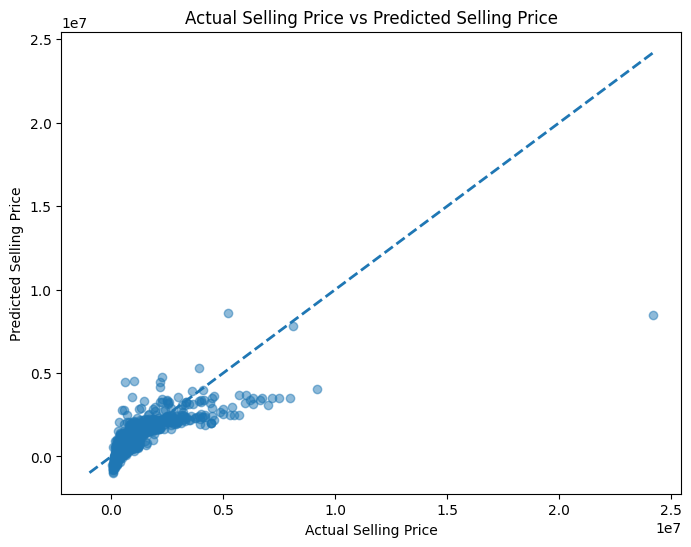

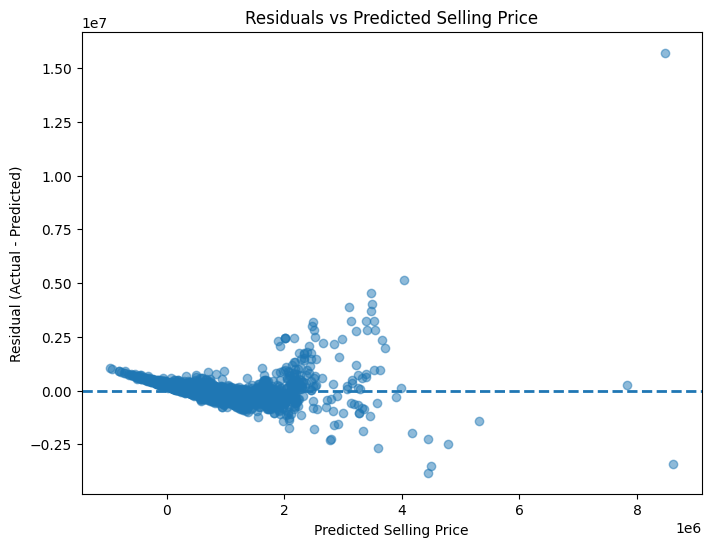

10 observations with the largest prediction errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
2796,24200000,8.483885e+06,1.571612e+07,1.571612e+07
2362,9200000,4.036108e+06,5.163892e+06,5.163892e+06
1382,8000000,3.477296e+06,4.522704e+06,4.522704e+06
841,7500000,3.481968e+06,4.018032e+06,4.018032e+06
246,7000000,3.092218e+06,3.907782e+06,3.907782e+06
26,625000,4.449522e+06,-3.824522e+06,3.824522e+06
1286,7199000,3.477296e+06,3.721704e+06,3.721704e+06
2528,999000,4.497734e+06,-3.498734e+06,3.498734e+06
2050,5200000,8.617762e+06,-3.417762e+06,3.417762e+06
1092,6645000,3.388240e+06,3.256760e+06,3.256760e+06



Maximum absolute error:
15716115.328019934

Mean absolute error:
270044.52345451905

Median absolute error:
170824.2919013661

Mean residual:
-9555.808429696512


In [ ]:
# TASK 19: VISUALIZE AND ANALYZE MODEL PERFORMANCE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Convert values to 1-D arrays
# ---------------------------------------------------------

actual = ytest.flatten()
predicted = y_pred.flatten()
residuals = actual - predicted

# ---------------------------------------------------------
# Step 2: Actual vs Predicted Selling Price Plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(actual, predicted, alpha=0.5)

# Reference line for perfect prediction
min_price = min(actual.min(), predicted.min())
max_price = max(actual.max(), predicted.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual Selling Price vs Predicted Selling Price')

plt.show()


# ---------------------------------------------------------
# Step 3: Residual Plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(predicted, residuals, alpha=0.5)

# Horizontal zero-error reference line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted Selling Price')

plt.show()


# ---------------------------------------------------------
# Step 4: Identify observations with large errors
# ---------------------------------------------------------

# Absolute prediction error
absolute_errors = np.abs(residuals)

# Create a table
error_table = pd.DataFrame({
    'Actual Selling Price': actual,
    'Predicted Selling Price': predicted,
    'Residual': residuals,
    'Absolute Error': absolute_errors
})

# Sort by largest absolute error
largest_errors = error_table.sort_values(
    by='Absolute Error',
    ascending=False
)

print("10 observations with the largest prediction errors:")
display(largest_errors.head(10))


# ---------------------------------------------------------
# Step 5: Calculate useful error information
# ---------------------------------------------------------

print("\nMaximum absolute error:")
print(absolute_errors.max())

print("\nMean absolute error:")
print(absolute_errors.mean())

print("\nMedian absolute error:")
print(np.median(absolute_errors))

print("\nMean residual:")
print(residuals.mean())

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [ ]:
# ============================================================
# TASK 20: CONCLUSION
# ============================================================

# Create coefficient table
feature_names = [
    'Intercept',
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': beta
})

# Remove intercept for feature comparison
feature_importance = coefficient_table.iloc[1:].copy()

# Calculate absolute coefficient
feature_importance['Absolute Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

# Sort by influence
feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print("Features Ranked by Relative Influence:")
display(feature_importance)

print("\nMost Influential Feature:")
print(feature_importance.iloc[0]['Feature'])

print(
    "Coefficient:",
    feature_importance.iloc[0]['Coefficient']
)

Features Ranked by Relative Influence:


,Feature,Coefficient,Absolute Coefficient
1,vehicle_age,-65014.779175,65014.779175
5,max_power,15754.377629,15754.377629
3,mileage,13753.057078,13753.057078
6,seats,857.129320,857.129320
4,engine,75.815851,75.815851
2,km_driven,-0.677550,0.677550



Most Influential Feature:
vehicle_age
Coefficient: -65014.77917516278


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.